In [1]:
import sys
sys.path.insert(0, "..")

import json
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%load_ext autoreload
%autoreload 2

ROOT = Path().cwd().parent
ROOT

PosixPath('/Users/I550854/Documents/Master Thesis/gdpa-benchmark')

In [2]:
pattern = str(ROOT / 'results/mas/2026052*_T15_W1_topofc*_es3.json')
all_files = sorted(glob.glob(pattern))

# keep only q0–q19
files = [
    f for f in all_files
    if (m := re.search(r'_q(\d+)_R', f)) and int(m.group(1)) <= 19
]

data = {}
for f in files:
    d = json.load(open(f))
    qid = int(d['question_id'])
    data[qid] = d

print(f"Loaded {len(data)} questions: {sorted(data.keys())}")
for qid, d in sorted(data.items()):
    print(f"  q{qid:>2}  GT={d['ground_truth']}  R={d['R']}")

Loaded 20 questions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  q 0  GT=C  R=20
  q 1  GT=A  R=20
  q 2  GT=D  R=20
  q 3  GT=C  R=20
  q 4  GT=C  R=10
  q 5  GT=D  R=10
  q 6  GT=D  R=10
  q 7  GT=A  R=10
  q 8  GT=D  R=10
  q 9  GT=A  R=10
  q10  GT=A  R=10
  q11  GT=B  R=10
  q12  GT=D  R=10
  q13  GT=B  R=10
  q14  GT=D  R=10
  q15  GT=A  R=10
  q16  GT=C  R=10
  q17  GT=C  R=10
  q18  GT=A  R=10
  q19  GT=D  R=10


In [3]:
def votes_at(rep, t):
    return [a['vote'] for a in rep['trajectory'][t]['phase_b']]

records = []
for qid, d in sorted(data.items()):
    gt = d['ground_truth']
    for rep in d['repetitions']:
        t0_votes = votes_at(rep, 0)
        final_votes = votes_at(rep, -1)
        records.append({
            'qid': qid,
            'gt': gt,
            'agent_acc_t0': np.mean([v == gt for v in t0_votes]),
            'agent_acc_final': np.mean([v == gt for v in final_votes]),
            'system_correct': rep['correct'],
            'rounds_run': len(rep['trajectory']) - 1,
        })

df = pd.DataFrame(records)

per_q = df.groupby('qid').agg(
    gt=('gt', 'first'),
    agent_acc_t0=('agent_acc_t0', 'mean'),
    agent_acc_final=('agent_acc_final', 'mean'),
    system_acc=('system_correct', 'mean'),
    mean_rounds=('rounds_run', 'mean'),
    R=('qid', 'count'),
).reset_index()

print(per_q.round(3).to_string(index=False))

 qid gt  agent_acc_t0  agent_acc_final  system_acc  mean_rounds  R
   0  C         0.988            1.000        1.00         3.00 20
   1  A         0.662            0.750        0.75         4.45 20
   2  D         0.938            1.000        1.00         3.00 20
   3  C         0.000            0.050        0.05         3.60 20
   4  C         1.000            1.000        1.00         3.00 10
   5  D         0.425            0.600        0.60         4.40 10
   6  D         0.575            0.900        0.90         4.40 10
   7  A         0.900            0.900        0.90         3.40 10
   8  D         0.350            0.500        0.50         4.60 10
   9  A         0.775            0.825        0.90         7.30 10
  10  A         0.000            0.000        0.00         3.10 10
  11  B         1.000            1.000        1.00         3.00 10
  12  D         0.750            0.800        0.80         3.80 10
  13  B         0.800            1.000        1.00         3.9

## Per-question: t=0 agent accuracy vs system accuracy

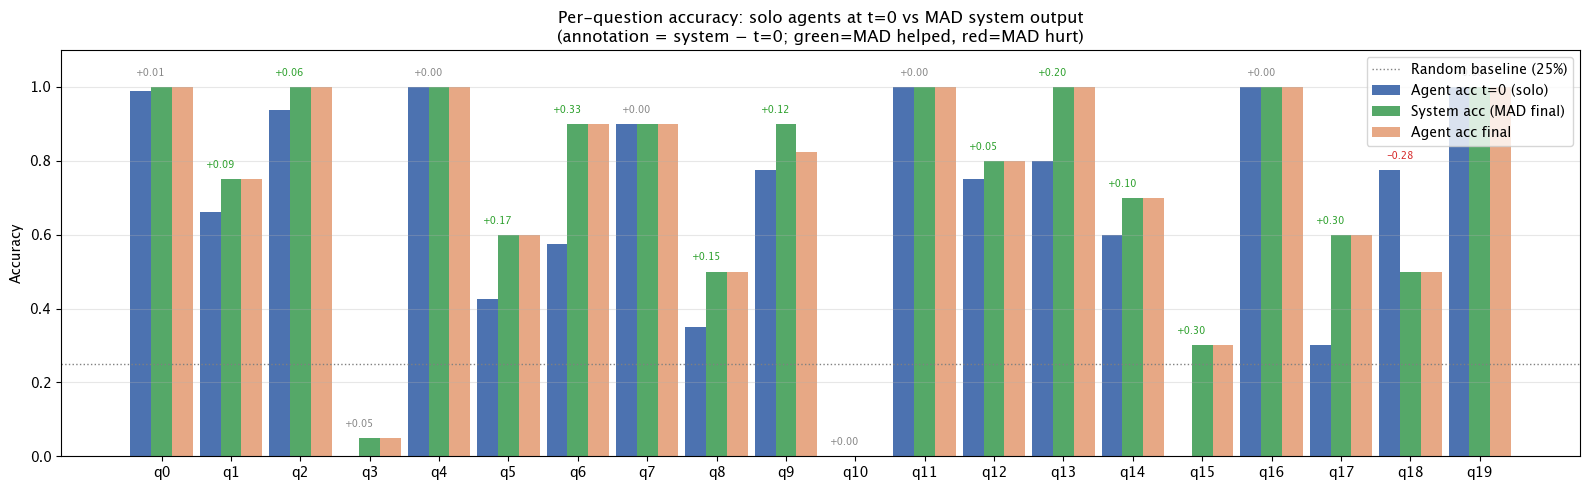

In [4]:
x = np.arange(len(per_q))
width = 0.3
qlabels = [f"q{row.qid}" for _, row in per_q.iterrows()]

fig, ax = plt.subplots(figsize=(16, 5))

bars_t0  = ax.bar(x - width, per_q['agent_acc_t0'],    width, label='Agent acc t=0 (solo)',  color='#4C72B0')
bars_sys = ax.bar(x,          per_q['system_acc'],      width, label='System acc (MAD final)', color='#55A868')
bars_af  = ax.bar(x + width,  per_q['agent_acc_final'], width, label='Agent acc final',        color='#DD8452', alpha=0.7)

# arrow/color overlay to show direction of change t0 -> system
for i, row in per_q.iterrows():
    delta = row['system_acc'] - row['agent_acc_t0']
    color = '#2ca02c' if delta > 0.05 else ('#d62728' if delta < -0.05 else '#888888')
    ax.annotate(
        f"{delta:+.2f}",
        xy=(i - width/2, max(row['agent_acc_t0'], row['system_acc']) + 0.03),
        ha='center', fontsize=7, color=color, fontweight='bold'
    )

ax.axhline(0.25, color='gray', linestyle=':', linewidth=1, label='Random baseline (25%)')
ax.set_xticks(x)
ax.set_xticklabels(qlabels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Per-question accuracy: solo agents at t=0 vs MAD system output\n(annotation = system − t=0; green=MAD helped, red=MAD hurt)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Scatter: t=0 accuracy vs system accuracy

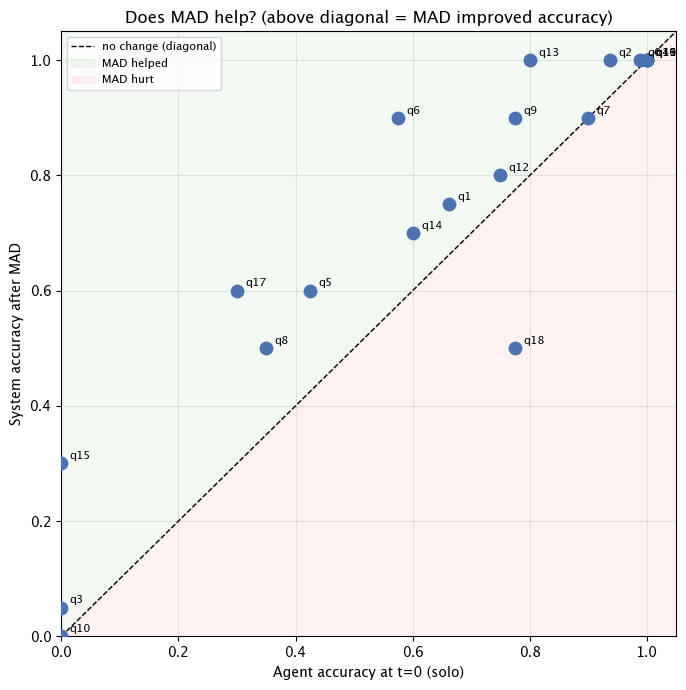

MAD helped (>+5pp): 10/20 questions
MAD hurt   (>-5pp): 1/20 questions
Neutral    (±5pp):  9/20 questions

Mean t=0 acc:    0.642
Mean system acc: 0.725
Mean delta:      +0.083


In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(per_q['agent_acc_t0'], per_q['system_acc'], s=80, color='#4C72B0', zorder=3)

for _, row in per_q.iterrows():
    ax.annotate(f"q{row.qid}", (row['agent_acc_t0'], row['system_acc']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)

lims = [0, 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='no change (diagonal)')
ax.fill_between(lims, lims, [1.05]*2, alpha=0.05, color='green', label='MAD helped')
ax.fill_between(lims, [0]*2,  lims,  alpha=0.05, color='red',   label='MAD hurt')

ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.set_xlabel('Agent accuracy at t=0 (solo)')
ax.set_ylabel('System accuracy after MAD')
ax.set_title('Does MAD help? (above diagonal = MAD improved accuracy)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_helped  = (per_q['system_acc'] > per_q['agent_acc_t0'] + 0.05).sum()
n_hurt    = (per_q['system_acc'] < per_q['agent_acc_t0'] - 0.05).sum()
n_neutral = len(per_q) - n_helped - n_hurt
print(f"MAD helped (>+5pp): {n_helped}/{len(per_q)} questions")
print(f"MAD hurt   (>-5pp): {n_hurt}/{len(per_q)} questions")
print(f"Neutral    (±5pp):  {n_neutral}/{len(per_q)} questions")
print(f"\nMean t=0 acc:    {per_q['agent_acc_t0'].mean():.3f}")
print(f"Mean system acc: {per_q['system_acc'].mean():.3f}")
print(f"Mean delta:      {(per_q['system_acc'] - per_q['agent_acc_t0']).mean():+.3f}")

## Delta distribution: system − t=0

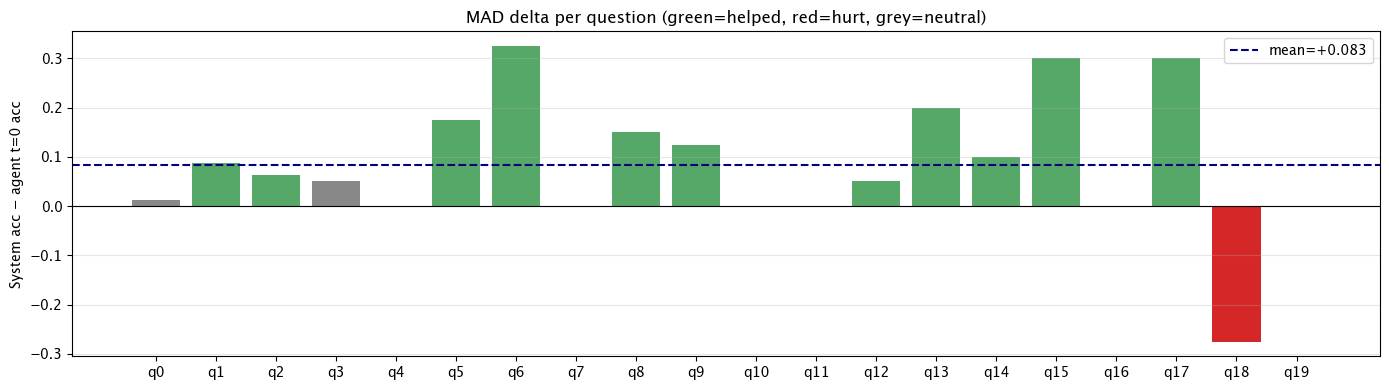

In [6]:
per_q['delta'] = per_q['system_acc'] - per_q['agent_acc_t0']
colors = ['#55A868' if d > 0.05 else ('#d62728' if d < -0.05 else '#888888') for d in per_q['delta']]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(per_q['qid'], per_q['delta'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(per_q['delta'].mean(), color='navy', linewidth=1.5, linestyle='--',
           label=f"mean={per_q['delta'].mean():+.3f}")
ax.set_xticks(per_q['qid'])
ax.set_xticklabels([f"q{q}" for q in per_q['qid']])
ax.set_ylabel('System acc − agent t=0 acc')
ax.set_title('MAD delta per question (green=helped, red=hurt, grey=neutral)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Mean rounds run per question (early stopping effect)

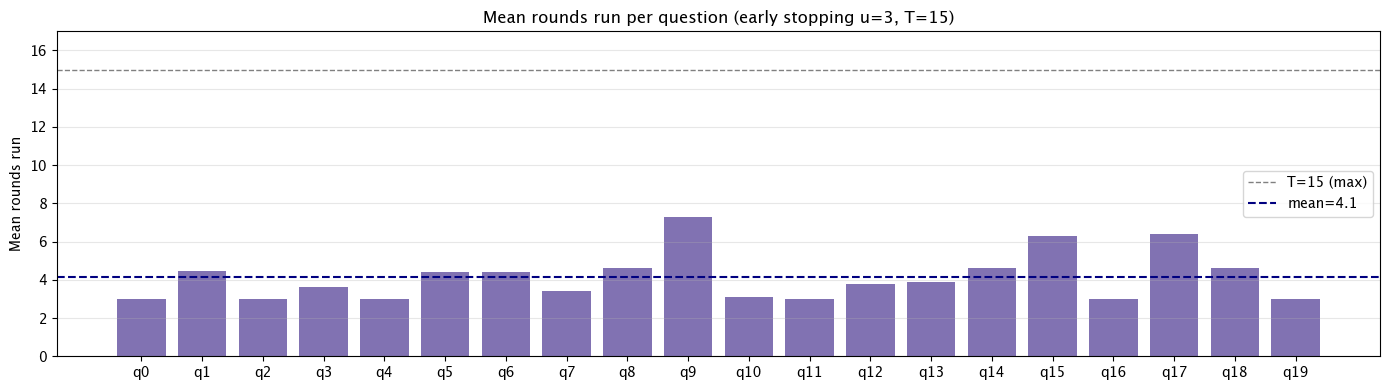

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(per_q['qid'], per_q['mean_rounds'], color='#8172B2')
ax.axhline(15, color='gray', linestyle='--', linewidth=1, label='T=15 (max)')
ax.axhline(per_q['mean_rounds'].mean(), color='navy', linewidth=1.5, linestyle='--',
           label=f"mean={per_q['mean_rounds'].mean():.1f}")
ax.set_xticks(per_q['qid'])
ax.set_xticklabels([f"q{q}" for q in per_q['qid']])
ax.set_ylabel('Mean rounds run')
ax.set_title('Mean rounds run per question (early stopping u=3, T=15)')
ax.set_ylim(0, 17)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

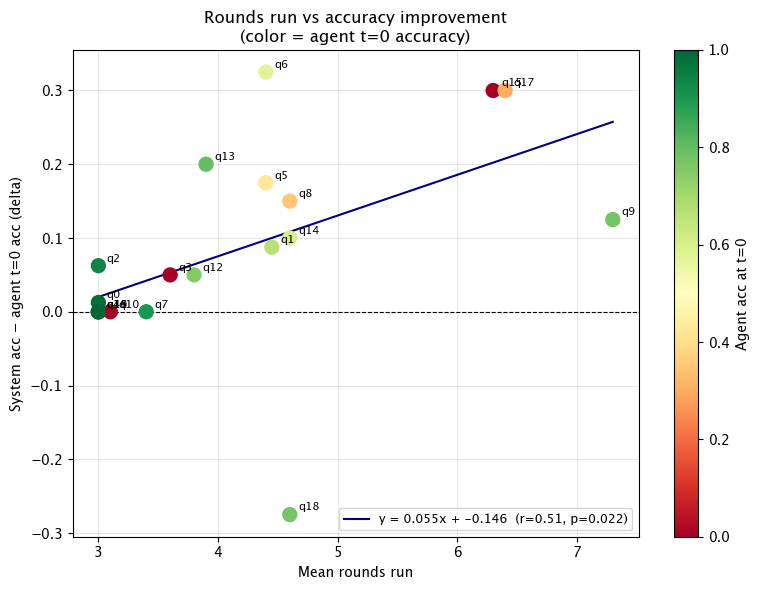

In [9]:
from scipy import stats

slope, intercept, r, p, _ = stats.linregress(per_q['mean_rounds'], per_q['delta'])

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(per_q['mean_rounds'], per_q['delta'],
                c=per_q['agent_acc_t0'], cmap='RdYlGn',
                s=100, vmin=0, vmax=1, zorder=3)

for _, row in per_q.iterrows():
    ax.annotate(f"q{row.qid}", (row['mean_rounds'], row['delta']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)

x_line = np.linspace(per_q['mean_rounds'].min(), per_q['mean_rounds'].max(), 100)
ax.plot(x_line, intercept + slope * x_line, color='navy', linewidth=1.5,
        label=f'y = {slope:.3f}x + {intercept:.3f}  (r={r:.2f}, p={p:.3f})')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean rounds run')
ax.set_ylabel('System acc − agent t=0 acc (delta)')
ax.set_title('Rounds run vs accuracy improvement\n(color = agent t=0 accuracy)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='Agent acc at t=0')
plt.tight_layout()
plt.show()


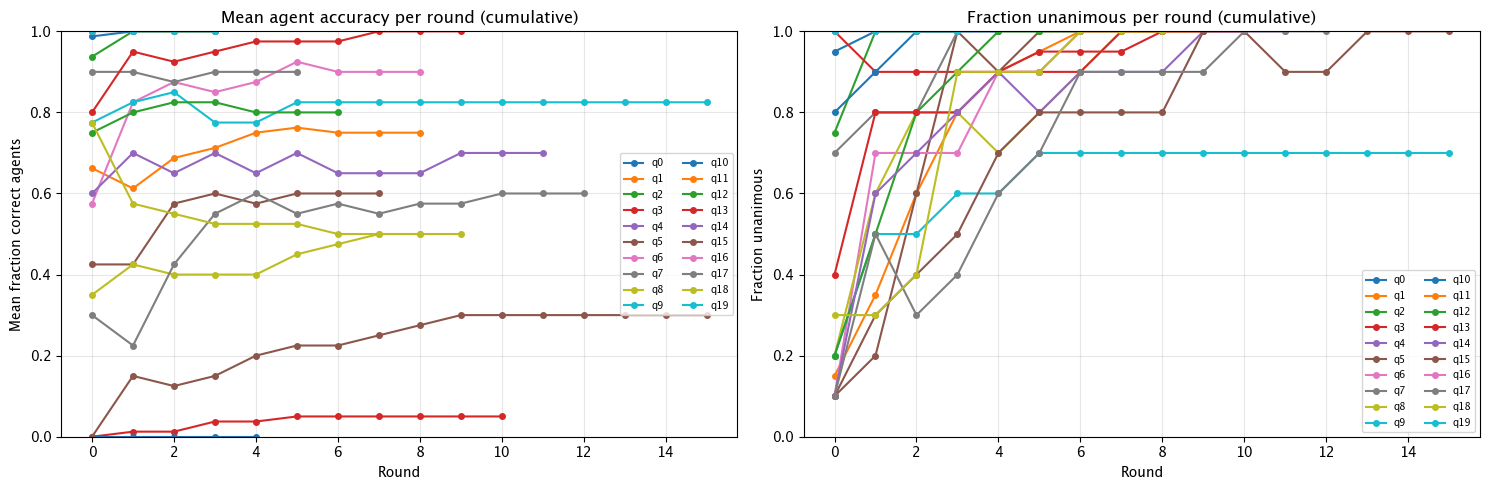

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for qid, d in sorted(data.items()):
    gt = d['ground_truth']
    T = max(len(rep['trajectory']) for rep in d['repetitions'])

    fc, fu = [], []
    for t in range(T):
        accs, unanims = [], []
        for rep in d['repetitions']:
            effective_t = min(t, len(rep['trajectory']) - 1)
            v = votes_at(rep, effective_t)
            accs.append(np.mean([x == gt for x in v]))
            unanims.append(len(set(v)) == 1)
        fc.append(np.mean(accs))
        fu.append(np.mean(unanims))

    axes[0].plot(range(T), fc, marker='o', label=f'q{qid}', linewidth=1.5, markersize=4)
    axes[1].plot(range(T), fu, marker='o', label=f'q{qid}', linewidth=1.5, markersize=4)

for ax, title, ylabel in zip(
    axes,
    ['Mean agent accuracy per round (cumulative)', 'Fraction unanimous per round (cumulative)'],
    ['Mean fraction correct agents', 'Fraction unanimous'],
):
    ax.set_xlabel('Round')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
